# Morris Sensitivity Analysis – SnowToSwe (Win21 dataset)

Functionally equivalent to `morris_SNOWPACK/morris_sensitivity.ipynb`.  
Data source replaced with the **Win21 observational dataset** (long-term field SWE measurements from 15 Alpine stations, 1959–2022).  

Computes **Elementary Effect (Morris)** indices for all 7 ΔSnow parameters using
**SALib** (Herman & Usher, 2017; Iwanaga et al., 2022).  
Model input: daily HS from Win21 stations (various periods from 1959–2022).  
Output metric: mean NRMSE of modelled SWE vs observed SWE, evaluated **only on actual SWE observation dates** (biweekly field measurements, no interpolation).

| Parameter | Description | Lower | Default | Upper |
|-----------|-------------|------:|--------:|------:|
| `rho_max` | Maximum snow density [kg/m³] | 300 | 401.3 | 600 |
| `rho_null` | Fresh-snow density [kg/m³] | 50 | 81.2 | 200 |
| `c_ov` | Overburden compaction coefficient | 1e-6 | 5.1e-4 | 1e-3 |
| `k_ov` | Overburden density exponent | 0.01 | 0.38 | 10.0 |
| `k` | Viscosity density exponent | 0.01 | 0.030 | 0.2 |
| `tau` | New-snow threshold [m] | 0.01 | 0.024 | 0.2 |
| `eta_null` | Reference viscosity [Pa·s] | 1e6 | 8.5e6 | 2e7 |

Bounds from `calibration_SNOWPACK/dsnow_parameter_optimization_DE.R`.

## Schema differences: Win21 vs SNOWPACK dataset

| Property | SNOWPACK (`alpsolut_all.nc`) | Win21 (`Win21_all.nc`) | Adaptation |
|----------|------------------------------|------------------------|------------|
| Time resolution | Hourly → resampled to daily | **Already daily** | Skip `resample()` |
| Dimension order | `(station, time)` | `(station, time)` | No change |
| Time range | Oct 2023 – Jul 2025 (2 partial years) | **1960–2022 (with gap 1967–1996), 34 hydrological years with data** | `winter_years` updates automatically |
| Station count | 18 | **15** | No exclusion needed |
| SWE availability | Daily (model output) | **~biweekly field observations** (sparse, NaN on non-observation days) | Evaluate metric only on `~NaN` SWE dates |
| SWE units | mm | **mm** | No change |
| `n_valid` threshold | 10 | **3** (biweekly → ~5–20 obs/winter, some stations sparse) | Lowered |
| Excluded station | — | **none** | — |

All cells from § 2 onward (Morris sampling, model execution, analysis, plots) are **identical** to the SNOWPACK notebook.

In [1]:
import sys, os, io, contextlib, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from joblib import Parallel, delayed
from tqdm.auto import tqdm
from SALib.sample import morris as salib_sample
from SALib.analyze import morris as salib_analyze

# ── Project paths ─────────────────────────────────────────────────────────────
ROOT = Path("/Users/jakobwerkgarner/code/mt_dsnow")
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "snow_to_swe_master"))

from main import SnowToSwe
from plot_style import apply_style, C, ALPHA

warnings.filterwarnings("ignore")
apply_style()

# ── Morris settings ────────────────────────────────────────────────────────────
N_TRAJ     = 50    # number of Morris trajectories (≥30 recommended)
NUM_LEVELS = 6     # grid discretisation levels (even number)
N_JOBS     = -1    # parallel workers (-1 = all cores; 1 = sequential)
SEED       = 42

# ── Parameter space (from DE calibration bounds) ───────────────────────────────
PARAM_NAMES  = ["rho_max", "rho_null", "c_ov", "k_ov", "k", "tau", "eta_null"]
PARAM_LATEX  = [r"$\rho_{max}$", r"$\rho_0$", r"$c_{ov}$",
                r"$k_{ov}$",     r"$k$",       r"$\tau$", r"$\eta_0$"]
PARAM_BOUNDS = [
    [300,  600  ],  # rho_max
    [50,   200  ],  # rho_null
    [1e-6, 1e-3 ],  # c_ov
    [0.01, 10.0 ],  # k_ov
    [0.01, 0.2  ],  # k
    [0.01, 0.2  ],  # tau
    [1e6,  2e7  ],  # eta_null
]
K = len(PARAM_NAMES)

# SALib problem definition — used for both sampling and analysis
PROBLEM = {
    'num_vars': K,
    'names':    PARAM_NAMES,
    'bounds':   PARAM_BOUNDS,
}

# One colour per parameter (Okabe-Ito palette via C.CYCLE)
PARAM_COLORS = dict(zip(PARAM_LATEX, C.CYCLE[:K]))

# ── Win21-specific constants ───────────────────────────────────────────────────
N_VALID_MIN = 3   # min SWE obs per block (biweekly → ~3–24 obs/winter)

/Users/jakobwerkgarner/miniforge3/envs/MT_dsnow/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 · Load data & build station×winter task list

In [2]:
DATA_PATH = ROOT / "calibration/calibration_data/raw_data/dsnow/Win21_calib/Win21_all.nc"

# ── Load — Win21 is already daily, no resampling needed ───────────────────────
ds_daily = xr.open_dataset(DATA_PATH)

times_daily = pd.to_datetime(ds_daily["time"].values)

# Hydrological year: Sep 1 → Aug 31  (same convention as calibration scripts)
hyd_year_d   = np.where(times_daily.month >= 9, times_daily.year, times_daily.year - 1)
winter_years = np.unique(hyd_year_d)

# ── Build (station, winter) task list ─────────────────────────────────────────
# Win21 dims are (station, time) — same as SNOWPACK dataset
station_names = ds_daily["station"].values
station_tasks = []   # list of (station_name, winter_year, hs_1d, swe_1d)

for stn in station_names:
    hs_full  = ds_daily["HS" ].sel(station=stn).values.astype(float)
    swe_full = ds_daily["SWE"].sel(station=stn).values.astype(float)

    for wy in winter_years:
        mask = hyd_year_d == wy
        hs  = pd.Series(hs_full[mask]).ffill(limit=3).fillna(0).clip(lower=0).values
        swe = swe_full[mask]   # sparse — NaN on non-observation days

        # Valid SWE obs: actual field measurements (non-NaN, > 5 mm)
        # N_VALID_MIN=3 because Win21 uses biweekly sampling → ~3–24 obs/winter
        n_valid = int(np.sum(~np.isnan(swe) & (swe > 5)))
        if n_valid < N_VALID_MIN or hs.max() < 0.05:
            continue

        # SnowToSwe requires hs[0] == 0 and hs[-1] == 0
        hs[0] = 0.0;  hs[-1] = 0.0

        station_tasks.append((stn, int(wy), hs, swe))

print(f"Stations           : {len(station_names)}")
print(f"Hydrological years : {list(winter_years)}")
print(f"Valid task blocks  : {len(station_tasks)}  (station × winter)")

Stations           : 15
Hydrological years : [np.int32(1959), np.int32(1960), np.int32(1961), np.int32(1962), np.int32(1963), np.int32(1964), np.int32(1965), np.int32(1966), np.int32(1967), np.int32(1997), np.int32(1998), np.int32(1999), np.int32(2000), np.int32(2001), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)]
Valid task blocks  : 134  (station × winter)


In [3]:
# ── Validation checks ─────────────────────────────────────────────────────────

# 1. SWE observation summary per station
print("SWE observation counts per station (used tasks only):")
stn_swe_counts = {}
for stn, wy, hs, swe in station_tasks:
    n = int(np.sum(~np.isnan(swe) & (swe > 5)))
    stn_swe_counts.setdefault(stn, []).append(n)

for stn, counts in sorted(stn_swe_counts.items()):
    total  = sum(counts)
    n_yrs  = len(counts)
    print(f"  {stn:30s}  {n_yrs} winter(s)  {total:3d} obs total  "
          f"[{min(counts)}–{max(counts)} obs/winter]")

# 2. Check for irregular SWE sampling intervals
print("\nSWE sampling interval check (all stations):")
irregular = []
for stn in station_names:
    swe_stn = ds_daily["SWE"].sel(station=stn).values
    obs_idx = np.where(~np.isnan(swe_stn))[0]
    if len(obs_idx) < 2:
        continue
    gaps    = np.diff(obs_idx)
    med_gap = int(np.median(gaps))
    max_gap = int(gaps.max())
    if max_gap > 60:
        irregular.append((stn, med_gap, max_gap))

if irregular:
    print("  Stations with gaps > 60 d (likely missing seasons):")
    for stn, med, mx in irregular:
        print(f"    {stn:30s}  median={med:3d} d  max={mx:4d} d  → NaN-masking handles this correctly")
else:
    print("  No station has a gap > 60 d.")

# 3. Time alignment spot-check
stn0, wy0, hs0, swe0 = station_tasks[0]
mask0   = hyd_year_d == wy0
n_days  = mask0.sum()
n_swe   = int(np.sum(~np.isnan(swe0) & (swe0 > 5)))
assert len(hs0) == n_days,  "HS length mismatch — time alignment error!"
assert len(swe0) == n_days, "SWE length mismatch — time alignment error!"
print(f"\n[OK] Time alignment verified: {stn0} / {wy0}–{wy0+1}  "
      f"({n_days} daily steps, {n_swe} SWE obs used)")

SWE observation counts per station (used tasks only):
  Davos_Flueelastr                6 winter(s)   50 obs total  [6–11 obs/winter]
  Davos_Flueelastr_dsnow          3 winter(s)   27 obs total  [8–10 obs/winter]
  Felbertauern                    14 winter(s)  240 obs total  [10–24 obs/winter]
  Holzgau                         14 winter(s)  216 obs total  [6–22 obs/winter]
  Innervillgraten                 13 winter(s)  211 obs total  [12–21 obs/winter]
  Klosters KW                     3 winter(s)   34 obs total  [10–12 obs/winter]
  Koessen                         13 winter(s)  157 obs total  [7–20 obs/winter]
  Ladis                           13 winter(s)  149 obs total  [4–17 obs/winter]
  Muerren                         6 winter(s)   54 obs total  [5–10 obs/winter]
  Obernberg                       14 winter(s)  192 obs total  [5–20 obs/winter]
  San Bernardino                  3 winter(s)   25 obs total  [6–11 obs/winter]
  Truebsee                        3 winter(s)   15 obs to

## 2 · Generate Morris sample (SALib)

In [4]:
# SALib generates N*(k+1) parameter sets arranged as N trajectories of k+1 points.
# optimal_trajectories=None uses the standard random design (Morris 1991).
X_flat = salib_sample.sample(
    PROBLEM,
    N          = N_TRAJ,
    num_levels = NUM_LEVELS,
    seed       = SEED,
)

print(f"Trajectories       : {N_TRAJ}")
print(f"Total model runs   : {len(X_flat)}  ({N_TRAJ} × {K+1})")  # N*(k+1) = 400

Trajectories       : 50
Total model runs   : 400  (50 × 8)


## 3 · Run Morris

In [5]:
def _nrmse_one_block(hs, swe_obs, params):
    """Run SnowToSwe on one (station, winter) block; returns NRMSE or NaN.

    For Win21, swe_obs is sparse (biweekly field measurements).  The valid
    mask selects only actual observation dates — no interpolation is used.
    """
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            model    = SnowToSwe(**params)
            swe_pred = model.convert_list(hs.tolist(), timestep=24, verbose=False)
    except (IndexError, ValueError, TypeError, RuntimeError):
        return np.nan

    if swe_pred is None:
        return np.nan

    swe_pred = np.asarray(swe_pred)

    if len(swe_pred) != len(hs):
        return np.nan

    valid = ~np.isnan(swe_obs) & (swe_obs > 5)   # actual observation dates only
    if valid.sum() < N_VALID_MIN:
        return np.nan

    rmse = np.sqrt(np.mean((swe_pred[valid] - swe_obs[valid]) ** 2))
    return float(rmse / swe_obs[valid].mean())


def evaluate_param_set(param_vec, tasks):
    """Mean NRMSE across all valid (station × winter) blocks for one param set."""
    import sys
    sys.path.insert(0, "/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master")

    params  = dict(zip(PARAM_NAMES, param_vec))
    nrmses  = [_nrmse_one_block(hs, swe, params) for _, _, hs, swe in tasks]
    valid   = [v for v in nrmses if not np.isnan(v)]
    return float(np.mean(valid)) if valid else np.nan


# ── Parallel execution ────────────────────────────────────────────────────────
Y_list = []
with tqdm(total=len(X_flat), desc="Morris runs", unit="param-set") as pbar:
    for y in Parallel(n_jobs=N_JOBS, return_as="generator")(
        delayed(evaluate_param_set)(x, station_tasks) for x in X_flat
    ):
        Y_list.append(y)
        pbar.update(1)

Y_flat = np.array(Y_list)

print(f"\nFinished. NaN results: {np.isnan(Y_flat).sum()} / {len(Y_flat)}")
print(f"NRMSE range: [{np.nanmin(Y_flat):.3f}, {np.nanmax(Y_flat):.3f}]")

Morris runs:   0%|          | 0/400 [00:00<?, ?param-set/s]/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:292: RuntimeWarning: overflow encountered in exp
  x = ts * EARTH_GRAVITATIONAL_ACCELERATION * swe_hat_d[i] * exp(-self.k * rho_d)  # yesterday
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:299: RuntimeWarning: overflow encountered in exp
  h_dd_cor = np.array(h_d) / (1 + (np.array(swe_hat_d) * EARTH_GRAVITATIONAL_ACCELERATION * ts) / np.array(eta_cor) * exp(
Mor


Finished. NaN results: 0 / 400
NRMSE range: [0.234, 1.116]


## 4 · Compute Morris indices (SALib)

In [6]:
# SALib returns a dict with keys: mu, mu_star, sigma, mu_star_conf
Si = salib_analyze.analyze(
    PROBLEM,
    X_flat,
    Y_flat,
    num_levels      = NUM_LEVELS,
    num_resamples   = 1000,   # bootstrap resamples for mu_star_conf
    print_to_console= False,
    seed            = SEED,
)

results = pd.DataFrame({
    "parameter"   : PARAM_LATEX,
    "name"        : PARAM_NAMES,
    "mu_star"     : Si["mu_star"],
    "mu_star_conf": Si["mu_star_conf"],   # 95 % bootstrap CI half-width
    "mu"          : Si["mu"],
    "sigma"       : Si["sigma"],
}).sort_values("mu_star", ascending=False).reset_index(drop=True)

display(results[["name", "mu_star", "mu_star_conf", "mu", "sigma"]]
        .rename(columns={"name": "parameter", "mu_star": "μ*",
                         "mu_star_conf": "μ* 95%-CI", "mu": "μ", "sigma": "σ"})
        .style.format({"μ*": "{:.4f}", "μ* 95%-CI": "±{:.4f}", "μ": "{:.4f}", "σ": "{:.4f}"})
        .background_gradient(subset="μ*", cmap="YlOrRd"))

,parameter,μ*,μ* 95%-CI,μ,σ
0,rho_null,0.3518,±0.0679,-0.0927,0.4199
1,tau,0.2471,±0.0331,0.1152,0.2525
2,rho_max,0.1926,±0.0686,0.1748,0.2573
3,k,0.1801,±0.0749,0.0127,0.3318
4,eta_null,0.0607,±0.0329,-0.0173,0.1332
5,k_ov,0.0317,±0.0130,-0.0130,0.0566
6,c_ov,0.0262,±0.0131,0.0034,0.0538


## 5 · Plots

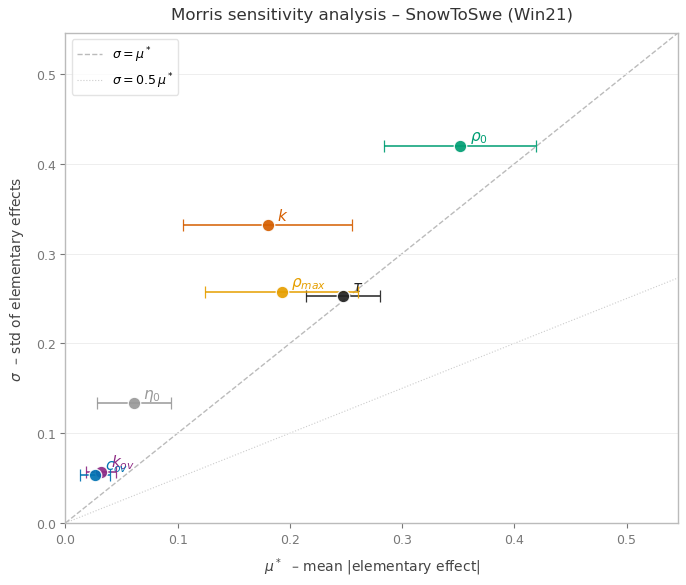

In [7]:
# ── Plot 1: μ* vs σ  (Morris chart) ──────────────────────────────────────────
#
# Parameters above the σ = μ* line have strong interactions / nonlinearity.
# Parameters near the origin are non-influential.

fig, ax = plt.subplots(figsize=(7, 6))

lim = max(results["mu_star"].max(), results["sigma"].max()) * 1.3
ax.plot([0, lim], [0, lim],       ls="--", lw=1.0, color="#BBBBBB", zorder=0, label=r"$\sigma = \mu^*$")
ax.plot([0, lim], [0, 0.5 * lim], ls=":",  lw=0.8, color="#CCCCCC", zorder=0, label=r"$\sigma = 0.5\,\mu^*$")

for _, row in results.iterrows():
    col = PARAM_COLORS[row["parameter"]]
    ax.errorbar(
        row["mu_star"], row["sigma"],
        xerr=row["mu_star_conf"],   # 95 % bootstrap CI from SALib
        fmt="o", ms=9, color=col, ecolor=col, elinewidth=1.2,
        capsize=4, zorder=4, alpha=0.92,
        markeredgecolor="white", markeredgewidth=0.9,
    )
    ax.annotate(
        row["parameter"],
        xy=(row["mu_star"], row["sigma"]),
        xytext=(7, 4), textcoords="offset points",
        fontsize=11, color=col, fontweight="bold",
    )

ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel(r"$\mu^*$  – mean $|$elementary effect$|$", labelpad=7)
ax.set_ylabel(r"$\sigma$  – std of elementary effects",   labelpad=7)
ax.set_title("Morris sensitivity analysis – SnowToSwe (Win21)", pad=10)
ax.legend(loc="upper left", fontsize=9, framealpha=0.8)

plt.tight_layout()
plt.savefig("morris_scatter.png")
plt.show()

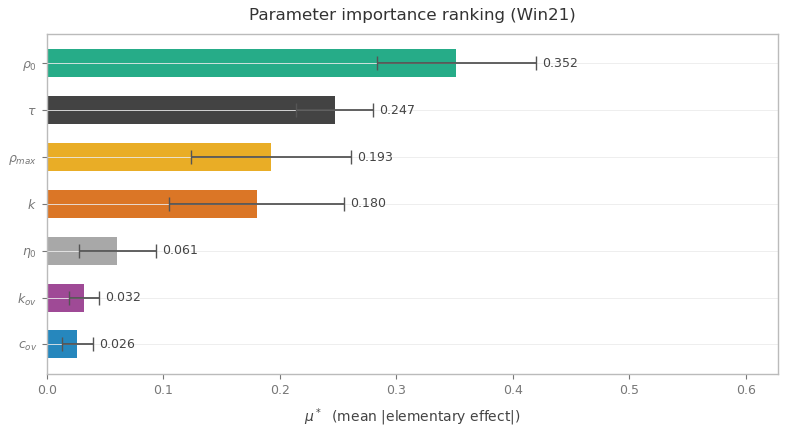

In [8]:
# ── Plot 2: μ* ranking bar chart ──────────────────────────────────────────────

ranked = results.sort_values("mu_star", ascending=True)   # ascending → most important on top

fig, ax = plt.subplots(figsize=(8, 4.5))

colors = [PARAM_COLORS[p] for p in ranked["parameter"]]
ax.barh(
    ranked["parameter"], ranked["mu_star"],
    xerr   = ranked["mu_star_conf"],   # 95 % bootstrap CI from SALib
    color  = colors,
    height = 0.6,
    alpha  = 0.85,
    error_kw = dict(elinewidth=1.3, ecolor="#555555", capsize=5),
)

for _, row in ranked.iterrows():
    ax.text(row["mu_star"] + row["mu_star_conf"] + lim * 0.01,
            row["parameter"], f"{row['mu_star']:.3f}",
            va="center", fontsize=9, color="#444444")

ax.set_xlabel(r"$\mu^*$  (mean $|$elementary effect$|$)", labelpad=7)
ax.set_title("Parameter importance ranking (Win21)", pad=10)
ax.set_xlim(0, lim * 1.15)

plt.tight_layout()
plt.savefig("morris_ranking.png")
plt.show()

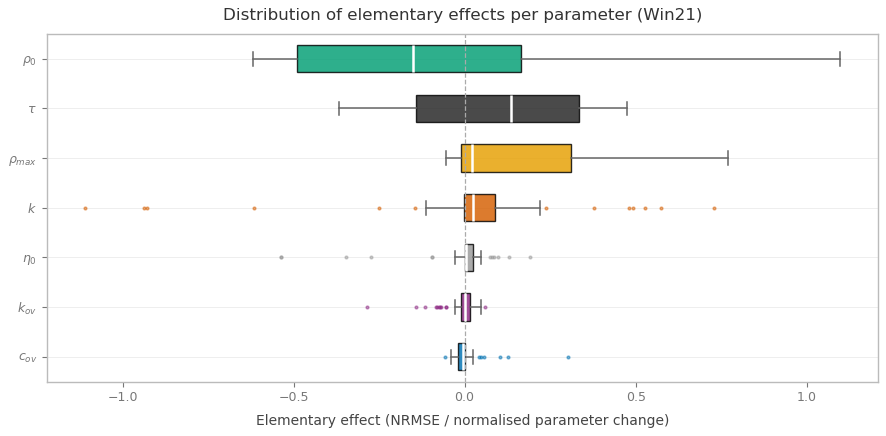

In [9]:
# ── Plot 3: EE distributions (box-plots per parameter) ───────────────────────
#
# SALib does not expose raw EEs, so we recompute them from the trajectory
# structure: consecutive points in each trajectory differ in exactly one
# parameter by one step Δ.  EE = ΔY / (Δx_j / range_j).

lo = np.array([b[0] for b in PARAM_BOUNDS])
hi = np.array([b[1] for b in PARAM_BOUNDS])

X_traj = X_flat.reshape(N_TRAJ, K + 1, K)   # (N, k+1, k)
Y_traj = Y_flat.reshape(N_TRAJ, K + 1)

EE_raw = [[] for _ in range(K)]
for r in range(N_TRAJ):
    for step in range(K):
        diff   = X_traj[r, step + 1] - X_traj[r, step]
        j      = int(np.argmax(np.abs(diff)))
        d_norm = diff[j] / (hi[j] - lo[j])
        if abs(d_norm) > 1e-12:
            EE_raw[j].append((Y_traj[r, step + 1] - Y_traj[r, step]) / d_norm)

order          = results.sort_values("mu_star", ascending=True).index.tolist()
labels_ordered = [results.loc[i, "parameter"] for i in order]
colors_ordered = [PARAM_COLORS[lbl] for lbl in labels_ordered]

name_to_idx = {n: i for i, n in enumerate(PARAM_NAMES)}
ee_data     = [EE_raw[name_to_idx[results.loc[i, "name"]]] for i in order]

fig, ax = plt.subplots(figsize=(9, 4.5))

bp = ax.boxplot(
    ee_data,
    vert        = False,
    labels      = labels_ordered,
    patch_artist= True,
    widths      = 0.55,
    flierprops  = dict(marker=".", markersize=4, alpha=0.5),
    medianprops = dict(color="white", linewidth=1.8),
)
for patch, col in zip(bp["boxes"], colors_ordered):
    patch.set_facecolor(col);  patch.set_alpha(0.82)
for whisker in bp["whiskers"] + bp["caps"]:
    whisker.set_color("#666666");  whisker.set_linewidth(1.1)
for flier, col in zip(bp["fliers"], colors_ordered):
    flier.set_markerfacecolor(col);  flier.set_markeredgecolor(col)

ax.axvline(0, color="#AAAAAA", lw=0.9, ls="--")
ax.set_xlabel("Elementary effect (NRMSE / normalised parameter change)", labelpad=7)
ax.set_title("Distribution of elementary effects per parameter (Win21)", pad=10)

plt.tight_layout()
plt.savefig("morris_ee_distributions.png")
plt.show()